# Transformers for time series: attention, patches, and inverted axes

Two episodes ago we replaced hand-crafted lag features with recurrent networks; last
episode we taught those networks to transfer knowledge between series. Both were built
on the same computational primitive: a cell that reads the series *one step at a time*,
folding everything it has seen into a hidden state. That primitive has a famous rival.
Since 2017, the **transformer** — a network built entirely from *attention*, with no
recurrence at all — has swallowed natural language processing, computer vision, and
audio. Time series forecasting is the one domain where its takeover remains genuinely
contested: a one-layer linear model embarrassed a generation of sophisticated
transformers in a widely cited 2023 paper, and the architectures that eventually made
attention work for forecasting had to rethink what a "token" even is.

That contested history is exactly what makes the topic teachable. The plan:

1. **Groundwork** — one store, fifty item-level demand series, treated for the first
   time in this series as a genuinely *multivariate* forecasting problem: predict all
   fifty series jointly, two weeks ahead. Plus the naive baselines every method must beat.
2. **The incumbents** — GRU and LSTM forecasters, the architecture family of the last
   two episodes, scaled up to the multivariate task. They set the bar.
3. **Attention from first principles** — scaled dot-product attention in a few lines of
   NumPy, a hands-on demonstration of its superpower (any timestep can look at any
   other, directly) and of its blind spot (it is *permutation-invariant*: shuffle the
   past and the output does not flinch), and the positional encodings meant to patch
   that blind spot.
4. **The transformer ladder** — four architectures, each changing exactly one thing:
   a **vanilla transformer** treating every timestamp as a token; a **linear
   reality check** in the spirit of DLinear; a **patch transformer** (PatchTST) that
   tokenizes two-week *segments* instead of single days and treats every channel
   independently; and an **inverted transformer** (iTransformer) that flips the axes —
   one token per *series*, attention across *channels* instead of across time.
5. **When transformers win** — a lookback-length sweep. Attention's constant-length
   path to the distant past pays off once the window is long enough to contain last
   year's seasonality; recurrence degrades as the window grows.
6. **When they are overkill** — a rematch on the univariate Melbourne temperature
   series from two episodes ago: small data, short window, one channel. The GRU matches
   the transformer at a fraction of the parameters and training time, and a linear
   model nearly matches both.

Everything runs in Keras 3 on the PyTorch backend, accelerated by the Mac's own GPU.
As always: chronological splits, naive baselines first, and the numbers are reported
as they came out — including the ones that are inconvenient for the fashionable
architecture.

# Setup

In [1]:
# Standard library imports
import os
import time
import warnings

# choose the numerical engine BEFORE keras is imported — this line must come first
os.environ['KERAS_BACKEND'] = 'torch'

# Third-party imports: core data
import numpy as np
import pandas as pd

# Third-party imports: deep learning (Keras 3 on the PyTorch backend)
import torch
import keras
from keras.models import Sequential, Model
from keras.layers import (Input, Dense, GRU, LSTM, Reshape, Permute, Flatten,
                          MultiHeadAttention, LayerNormalization,
                          GlobalAveragePooling1D)
from keras.callbacks import EarlyStopping

# Third-party imports: metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Third-party imports: visualization
import matplotlib.pyplot as plt

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)

print(f'keras {keras.__version__}, backend: {keras.backend.backend()}')

keras 3.15.0, backend: torch


Walking through the imports. **`os`** is needed before anything else, because of the
single most important line in the cell: `os.environ['KERAS_BACKEND'] = 'torch'` tells
**Keras 3** to use **PyTorch** as its numerical engine, and it must run *before*
`import keras` — the backend choice is read once, at import time, and silently ignored
afterwards. We use the torch backend for the same reason as in the previous two
episodes: it is the route to the Mac's built-in GPU. **`time`** is new to the import
block and it is there on purpose — this episode's central question is not just "which
architecture is more accurate?" but "what does that accuracy *cost*?", so we will be
timing every training run.

From `keras.layers` we import the recurrent cells we already know (**`GRU`**,
**`LSTM`**) alongside the transformer building blocks that are new:

- **`MultiHeadAttention`** implements scaled dot-product attention — the layer this
  whole episode is about. We will first build a bare-bones version by hand in NumPy so
  that the Keras layer holds no mysteries, then use the library implementation for real
  models.
- **`LayerNormalization`** rescales each token's feature vector to zero mean and unit
  variance. Transformers are notoriously hard to train without it; every attention
  block we build wraps its sublayers in residual connections followed by exactly this
  layer.
- **`Permute`**, **`Reshape`**, and **`Flatten`** are humble tensor-plumbing layers,
  but they carry this episode's big ideas: `Reshape` will cut a window into patches,
  and `Permute` will perform the axis flip that turns a regular transformer into an
  *inverted* one.

The metrics imports and the `print` sanity check are unchanged from previous episodes —
the printout confirms which backend Keras actually bound to, which is worth verifying
every time given how easy it is to import things in the wrong order.

In [2]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 16
    img_dim2 = 6
    SEED = 42
    LOOK_BACK = 84            # input window: twelve weeks of history per prediction
    HORIZON = 14              # forecast two weeks ahead in a single shot
    N_ITEMS = 50              # all 50 item-level series of one store, jointly
    TEST_DAYS = 364           # final 52 weeks held out for testing
    VAL_DAYS = 182            # 26 weeks before that used for early stopping
    D_MODEL = 64              # width of a transformer token embedding
    N_HEADS = 4               # parallel attention heads per block
    N_BLOCKS = 2              # stacked encoder blocks
    PATCH_LEN = 14            # patch transformer: one token = two weeks
    RNN_UNITS = 64            # width of the recurrent hidden state
    EPOCHS = 100              # ceiling for every fit (early stopping decides)
    BATCH = 64                # minibatch size
    PATIENCE = 8              # early-stopping patience in epochs

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

# reproducibility: seeds Python, NumPy and the deep learning backend in one call
keras.utils.set_random_seed(CFG.SEED)

The `CFG` namespace, holding every knob in one place so no magic numbers appear inline
later. The forecasting task itself is pinned down by three of them: every model sees
`LOOK_BACK = 84` days (twelve weeks) of all `N_ITEMS = 50` series and must produce
`HORIZON = 14` days (two weeks) for all fifty series at once — a *direct* multi-step,
genuinely multivariate forecast. Twelve weeks is deliberately longer than the four-week
windows of the previous episodes: transformers are supposed to shine on long context,
and we want to give them room to do so (a dedicated experiment later varies this length
from four weeks to a full year).

The transformer hyperparameters are deliberately small. `D_MODEL = 64` is the width of
each token's internal representation, `N_HEADS = 4` means each attention layer looks at
the sequence from four subspaces in parallel, and `N_BLOCKS = 2` stacks two encoder
blocks. Published architectures go much bigger, but our training sets have a thousand
windows, not a million — an honest lesson of this episode is that on datasets this
size, small transformers are the only ones that stand a chance against
well-regularized simple models.

Splits are, as always in this series, chronological: the last `TEST_DAYS = 364` days
(52 weeks — a full year, so the test set contains every season) are the untouchable
test region, and the `VAL_DAYS = 182` days before them are the validation region that
early stopping watches. `keras.utils.set_random_seed` seeds Python's, NumPy's and
PyTorch's random generators in one call; we will re-issue it immediately before *every*
model build so that each experiment is reproducible in isolation, a discipline carried
over from the last episode.

In [3]:
# hardware: use the Apple silicon GPU when there is one, plain CPU otherwise
DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f'models will be created on: {DEVICE}')

models will be created on: mps


The same hardware ritual as the previous two episodes: **`torch.backends.mps.is_available()`**
returns `True` on Apple silicon Macs, where PyTorch can run on the integrated GPU via
the **MPS** (Metal Performance Shaders) backend. Every model factory below creates its
layers inside a `with keras.device(DEVICE):` block, so the weights live on the GPU and
both training and inference run there. Attention is a batch of large matrix
multiplications — precisely the workload GPUs exist for — so the speedup matters more
in this episode than it did for the small recurrent models of m11.

# Utils

In [4]:
def forecast_metrics(y_true, y_pred):
    """Return MAE and RMSE between two aligned arrays, rounded for display."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': float(np.round(mae, 3)), 'RMSE': float(np.round(rmse, 3))}

The scorecard, unchanged in spirit from previous episodes: **MAE** (mean absolute
error) reads as "typical miss, in units sold", and **RMSE** (root mean squared error)
punishes large misses more than small ones, which matters for demand planning where one
big stockout hurts more than seven small rounding errors. Both are computed on
*flattened* arrays — every item, every horizon day, every forecast origin pooled
together — so a single number summarizes a genuinely three-dimensional prediction
tensor. One caveat worth stating out loud: pooling across items means high-volume items
dominate the RMSE. That is a defensible choice (errors on big sellers cost more money)
but it is a choice; per-item weighting schemes exist and the ranking of methods below
does not change under the obvious alternatives.

In [5]:
def split_starts(n_days, look_back, horizon, val_start, test_start, test_stride=7):
    """Chronological train/val/test split of forecast origins (first predicted day)."""
    starts = np.arange(look_back, n_days - horizon + 1)
    train = starts[starts + horizon <= val_start]
    val = starts[(starts >= val_start) & (starts + horizon <= test_start)]
    test = starts[starts >= test_start][::test_stride]
    return train, val, test

The splitter thinks in **forecast origins**: an origin `s` is the index of the first
day to be predicted, so a window uses days `s - look_back` to `s - 1` as input and days
`s` to `s + horizon - 1` as the label. `np.arange` enumerates every origin that has a
full lookback behind it and a full horizon ahead; boolean masks then assign each origin
to a split. The assignment rule is conservative in exactly the direction that prevents
leakage: an origin belongs to *train* only if its **entire label** ends before the
validation region begins (`starts + horizon <= val_start`), so no training label ever
peeks into validation territory. Input windows of validation origins do reach back into
the training region — that is fine and unavoidable; the model may look at the past, it
may not be *graded* on data it trained on.

Test origins are thinned with `[::test_stride]`: with a stride of 7 we get one forecast
origin per week — 51 fourteen-day forecasts spread over the held-out year — rather than
364 origins that overlap almost entirely and would just average the same errors many
times over at 7× the compute.

In [6]:
def make_windows(values, starts, look_back, horizon):
    """Slice a (days, channels) array into (X, y) tensors at the given origins."""
    X = np.stack([values[s - look_back:s] for s in starts])
    y = np.stack([values[s:s + horizon] for s in starts])
    return X.astype('float32'), y.astype('float32')

The windowing workhorse, generalized from previous episodes to the multivariate case:
`values` is a two-dimensional `(days, channels)` array, so each slice
`values[s - look_back:s]` is itself a matrix — 84 days × 50 items — and `np.stack`
assembles them into tensors of shape `(samples, timesteps, channels)` for the inputs
and `(samples, horizon, channels)` for the labels. This is the same
`(samples, timesteps, features)` layout Keras recurrent layers have always expected;
the only novelty is that the label is now two-dimensional per sample too, because we
predict all fifty series jointly. The cast to `float32` halves memory and matches the
precision the GPU actually computes in.

In [7]:
# bookkeeping for the running theme of this episode: accuracy vs cost
train_times, param_counts = {}, {}

def fit_timed(name, model, X_tr, y_tr, X_va, y_va, batch=CFG.BATCH):
    """Fit with early stopping; record wall-clock time and parameter count."""
    early_stop = EarlyStopping(monitor='val_loss', patience=CFG.PATIENCE,
                               restore_best_weights=True)
    t0 = time.time()
    history = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                        epochs=CFG.EPOCHS, batch_size=batch,
                        callbacks=[early_stop], verbose=0)
    train_times[name] = round(time.time() - t0, 1)
    param_counts[name] = model.count_params()
    print(f'{name}: {len(history.history["loss"])} epochs, {train_times[name]}s, '
          f'{param_counts[name]:,} params, best val loss '
          f'{min(history.history["val_loss"]):.4f}')
    return model

The fitting wrapper from the last episode, upgraded with instrumentation. Every model
in this notebook is trained through this one function, which guarantees the comparison
is fair: identical epoch ceiling, identical **early stopping** (stop when validation
loss has not improved for `PATIENCE = 8` epochs, then roll back to the best weights via
`restore_best_weights=True`), identical batch size unless explicitly overridden.

The two module-level dictionaries are the episode's accountants. `time.time()` brackets
the `fit` call to capture wall-clock training time, and **`model.count_params()`**
returns the total number of trainable weights. Accuracy numbers without these two
columns tell only half the story — several results below are *only* interesting once
you see what they cost. The one-line summary printed per model (epochs used, seconds,
parameters, best validation loss) is worth reading as the notebook runs; early stopping
makes "100 epochs" mean very different things for different architectures.

In [8]:
def score_in_units(pred_z, starts, horizon, values, mean, std):
    """Undo standardization, then score against the raw series in original units."""
    pred = pred_z * std + mean
    actual = np.stack([values[s:s + horizon] for s in starts])
    return forecast_metrics(actual.ravel(), pred.ravel())

The evaluator undoes the standardization before scoring, exactly as in the previous
episode: networks train on z-scored data (we will see the scaling step in a moment),
but an RMSE in standard deviations is meaningless to a demand planner, so predictions
are mapped back with `pred_z * std + mean` — NumPy broadcasting applies each channel's
own scale — and compared against the **raw** series, re-sliced from `values` at the
same origins. Keeping the ground truth in original units and re-slicing it here, rather
than un-scaling the label tensors, means a bug in the scaling pipeline would show up as
a bad score instead of silently cancelling out.

In [9]:
def plot_test_forecast(pred_z, item, title, alpha=1.0):
    """Overlay one item's stitched weekly forecasts on the observed test year."""
    pred = pred_z[:, :, item - 1] * train_std[item - 1] + train_mean[item - 1]
    days, vals = [], []
    for i, s in enumerate(test_starts):
        days.extend(panel.index[s:s + 7])   # keep the first week of each origin
        vals.extend(pred[i, :7])
    plt.figure()
    panel[item].iloc[test_start:].plot(linewidth=2, label='observed', alpha=alpha)
    plt.plot(days, vals, 'g--', marker='o', markersize=3, linewidth=1.5,
             label='forecast (first week of each origin)')
    plt.title(title)
    plt.legend()
    plt.xlabel('')
    plt.show()

The forecast plotter, with one presentational decision to be upfront about. Our 51 test
forecasts are 14 days long but placed 7 days apart, so they overlap; plotting all of
them produces an unreadable thicket. The helper instead keeps the **first seven days of
each origin** and concatenates them into one continuous line — a fair reconstruction of
"what the model would have published each Monday". The observed series is the default
solid line, the forecast the series-standard green dashed line with markers. The helper
references `panel`, `test_starts` and the scaling constants defined in the groundwork
section below; Python only looks those names up when the function is *called*, so
defining it first is legal and keeps all helpers in one place.

# Groundwork: one store, fifty series, one task

In [10]:
# load five years of daily unit sales; carve out store 1 as a 50-channel panel
df = pd.read_csv(CFG.data_folder + 'train.csv', parse_dates=['date'])
panel = (df[df['store'] == 1]
         .pivot(index='date', columns='item', values='sales')
         .astype('float32'))
N_DAYS = len(panel)

print(f'{N_DAYS} days x {panel.shape[1]} items, '
      f'{panel.index.min().date()} to {panel.index.max().date()}')
panel.head(3)

1826 days x 50 items, 2013-01-01 to 2017-12-31


item,1,2,3,4,5,6,7,8,9,10,...,41,42,43,44,45,46,47,48,49,50
date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,13.0,33.0,15.0,10.0,11.0,31.0,25.0,33.0,18.0,37.0,...,6.0,21.0,22.0,20.0,37.0,30.0,17.0,21.0,18.0,30.0
2013-01-02,11.0,43.0,30.0,11.0,6.0,36.0,23.0,37.0,23.0,34.0,...,15.0,24.0,27.0,15.0,40.0,30.0,15.0,26.0,10.0,32.0
2013-01-03,14.0,23.0,14.0,8.0,8.0,18.0,34.0,38.0,25.0,32.0,...,5.0,14.0,19.0,11.0,42.0,30.0,5.0,25.0,17.0,25.0


The dataset is the Kaggle store-item demand panel used in the previous episode: five
years (2013–2017) of daily unit sales for 50 items in each of 10 stores. Last time we
treated its series one at a time; this time the *panel structure itself* is the point.
**`pivot`** reshapes the long table (one row per store-item-day) into a wide matrix
with one **row per day** and one **column per item** — after filtering to store 1, a
`1826 × 50` array where each column is one item's demand history. In this episode's
vocabulary each column is a **channel**, and the forecasting task is multivariate:
given twelve weeks of all fifty channels, predict the next two weeks of all fifty
channels simultaneously.

`parse_dates=['date']` converts the date strings to proper timestamps at load time so
the pivot index is a real `DatetimeIndex`, and `astype('float32')` converts the integer
sales counts to the precision the GPU trains in. The `head(3)` sanity check shows the
first three days across the first columns — small integers, as befits item-level retail
demand.

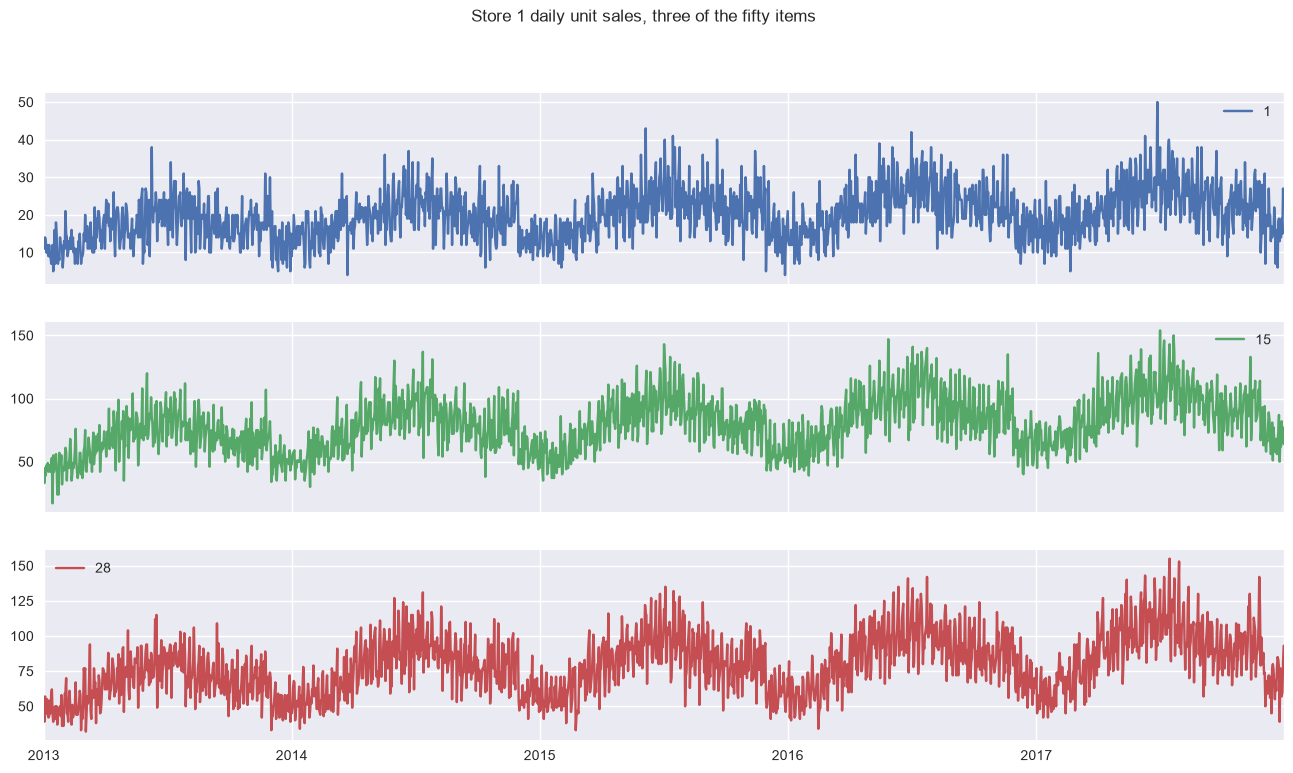

In [11]:
# a first look at three channels with very different volumes
panel[[1, 15, 28]].plot(subplots=True, figsize=(CFG.img_dim1, CFG.img_dim2 * 1.4),
                        xlabel='')
plt.suptitle('Store 1 daily unit sales, three of the fifty items', y=0.98)
plt.show()

A raw plot always precedes any modeling. Three items are enough to see everything that
matters. First, the **shared shape**: every panel shows the same summer-peaked annual
cycle, the same gentle multi-year growth, and (zoom in mentally) the same weekly
rhythm. Second, the **different scales**: the items differ several-fold in
volume, which is why per-channel standardization will be non-negotiable. Third, the
noise: day-to-day variation is substantial relative to the signal — item-level demand
counts are noisy in a way that store-level aggregates are not.

The shared shape is this episode's central empirical fact. If fifty channels rise and
fall together, then a model that can *look across channels* has fifty noisy views of
the same underlying seasonal signal to average over — and the architecture that ends up
winning this episode is precisely the one built to do that.

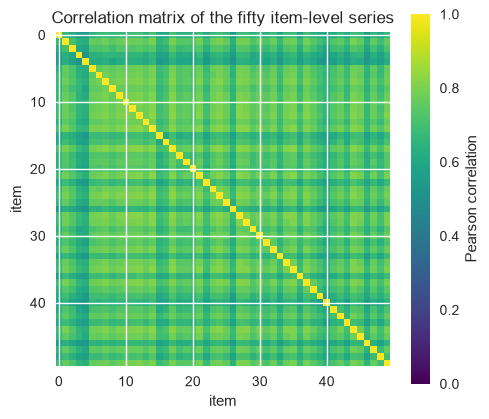

off-diagonal correlations: min 0.52, mean 0.71, max 0.83


In [12]:
# quantify the co-movement: correlation between every pair of channels
corr = np.corrcoef(panel.values.T)
off_diag = corr[np.triu_indices(CFG.N_ITEMS, k=1)]

plt.figure(figsize=(CFG.img_dim2 * 0.9, CFG.img_dim2 * 0.8))
plt.imshow(corr, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Pearson correlation')
plt.title('Correlation matrix of the fifty item-level series')
plt.xlabel('item')
plt.ylabel('item')
plt.show()

print(f'off-diagonal correlations: min {off_diag.min():.2f}, '
      f'mean {off_diag.mean():.2f}, max {off_diag.max():.2f}')

**`np.corrcoef`** expects variables in rows, hence the transpose: fed the `(50, 1826)`
array it returns the full `50 × 50` matrix of pairwise Pearson correlations, and
`np.triu_indices(..., k=1)` extracts the strictly-upper-triangle entries — the 1,225
distinct item pairs — for the summary statistics. The picture is strikingly uniform:
*every* pair of items is substantially positively correlated (mean around 0.7, and even
the weakest pair near 0.5), because every item shares the same annual and weekly
seasonality. There is no block structure, no cluster of unrelated products — one store,
one demand climate.

Keep this matrix in mind; it returns at the end of the transformer ladder. The
**iTransformer** architecture computes attention *between channels*, and comparing its
learned attention map against this correlation matrix is one of the most instructive
diagnostics in the notebook.

In [13]:
# chronological boundaries, then per-channel standardization fitted on train only
test_start = N_DAYS - CFG.TEST_DAYS
val_start = test_start - CFG.VAL_DAYS

train_mean = panel.values[:val_start].mean(axis=0)
train_std = panel.values[:val_start].std(axis=0)
z = (panel.values - train_mean) / train_std

print(f'train: {panel.index[0].date()} .. {panel.index[val_start - 1].date()} '
      f'({val_start} days)')
print(f'val:   {panel.index[val_start].date()} .. {panel.index[test_start - 1].date()} '
      f'({CFG.VAL_DAYS} days)')
print(f'test:  {panel.index[test_start].date()} .. {panel.index[-1].date()} '
      f'({CFG.TEST_DAYS} days)')

train: 2013-01-01 .. 2016-07-03 (1280 days)
val:   2016-07-04 .. 2017-01-01 (182 days)
test:  2017-01-02 .. 2017-12-31 (364 days)


The split is chronological, as always in this series: the final 52 weeks are the test
region (all of 2017, so every season appears in the evaluation), the 26 weeks before
them are the validation region, and everything earlier — a bit over three years — is
training data. Shuffling would let the model train on the future it is later graded on;
with strong trend and seasonality in the data, that inflates scores badly.

Standardization is **per channel** and **fitted on the training region only**:
`mean(axis=0)` and `std(axis=0)` reduce over days, producing one mean and one standard
deviation per item, and broadcasting rescales all 1,826 days of each channel with its
own training-era statistics. Two reasons, both already familiar. Statistically, using
full-sample statistics would leak the test year's level into the scaler. Practically,
the fifty channels differ several-fold in volume, and a shared network
minimizing pooled MSE would otherwise spend most of its capacity on the loudest items.
After z-scoring, every channel speaks at the same volume, and one unit of loss means
the same thing everywhere.

In [14]:
# window the panel for the main task: 84 days in, 14 days out
train_starts, val_starts, test_starts = split_starts(
    N_DAYS, CFG.LOOK_BACK, CFG.HORIZON, val_start, test_start)

X_train, y_train = make_windows(z, train_starts, CFG.LOOK_BACK, CFG.HORIZON)
X_val, y_val = make_windows(z, val_starts, CFG.LOOK_BACK, CFG.HORIZON)
X_test, y_test = make_windows(z, test_starts, CFG.LOOK_BACK, CFG.HORIZON)

print(f'X_train {X_train.shape}, y_train {y_train.shape}')
print(f'X_val   {X_val.shape},  y_val   {y_val.shape}')
print(f'X_test  {X_test.shape},   y_test  {y_test.shape}')

X_train (1183, 84, 50), y_train (1183, 14, 50)
X_val   (169, 84, 50),  y_val   (169, 14, 50)
X_test  (51, 84, 50),   y_test  (51, 14, 50)


The helpers do the work; the shapes tell the story. Training provides 1,183 windows,
each an `84 × 50` matrix of standardized history with a `14 × 50` matrix as its label —
direct multi-step forecasting of the whole panel in one network call, rather than the
recursive one-step feedback loop whose error-accumulation problems we studied in m11.
Validation contributes 169 origins for early stopping, and the test year is represented
by 51 weekly origins.

It is worth pausing on how *little* data 1,183 samples is by deep learning standards.
The transformer architectures we are about to build were introduced on datasets with
millions of tokens; here they get twelve hundred windows. That tension — modern
architecture, classical-statistics sample size — is the honest subtext of everything
that follows, and it is the typical situation in real forecasting work.

In [15]:
# helper bound to this task's globals, to keep later cells short
def score_test(pred_z):
    """Score standardized predictions for the 51 test origins, in sales units."""
    return score_in_units(pred_z, test_starts, CFG.HORIZON,
                          panel.values, train_mean, train_std)

# two seasonal naive baselines every model must beat
results = {}

naive_7 = np.stack([z[s - 7:s + CFG.HORIZON - 7] for s in test_starts])
results['seasonal naive (lag 7)'] = score_test(naive_7)

naive_364 = np.stack([z[s - 364:s + CFG.HORIZON - 364] for s in test_starts])
results['seasonal naive (lag 364)'] = score_test(naive_364)

results

{'seasonal naive (lag 7)': {'MAE': 8.466, 'RMSE': 11.019},
 'seasonal naive (lag 364)': {'MAE': 8.18, 'RMSE': 10.601}}

Baselines first, always. Both are **seasonal naive** forecasts, the "repeat what
happened one season ago" rule: the lag-7 version predicts each of the next 14 days with
the value from the same weekday last week, and the lag-364 version copies the same
window from 52 weeks ago — 364 rather than 365 so that weekdays align, which matters
enormously for retail demand. The slicing implements this directly on the standardized
panel: the window starting at `s - 364` *is* the forecast for the window starting at
`s`.

The yearly copy wins (RMSE 10.60 vs 11.02 units), which already teaches
something about this dataset: the annual cycle is strong enough that last year's
fortnight, which automatically gets the season right *and* the weekday pattern right,
beats last week's fortnight, which gets the weekday pattern right but drags along last
week's noise. Every learned model below must beat 10.60 to justify its existence.
The `results` dictionary starts its life here; every method appends to it, and the
final section sorts it into the episode's scoreboard.

# The incumbents: recurrent networks

In [16]:
def build_rnn(cell, look_back=CFG.LOOK_BACK, n_channels=CFG.N_ITEMS,
              horizon=CFG.HORIZON, units=CFG.RNN_UNITS):
    """Recurrent encoder + linear head for direct multivariate forecasting."""
    with keras.device(DEVICE):
        model = Sequential([
            Input(shape=(look_back, n_channels)),
            cell(units),
            Dense(horizon * n_channels),
            Reshape((horizon, n_channels)),
        ])
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(1e-3))
    return model

The reigning champion from the last two episodes, promoted to the multivariate task.
The factory takes the recurrent `cell` *class* — `GRU` or `LSTM` — as an argument, so
one function builds both incumbents with guaranteed-identical surroundings. The
architecture is the m11/m12 recipe: a recurrent encoder reads the 84 days step by step,
each step now seeing a **50-dimensional** input vector (one value per item), and after
the last step its `units = 64` hidden state — the network's entire memory of twelve
weeks — feeds a linear head producing all `14 × 50 = 700` outputs at once, which
`Reshape` folds back into the `(horizon, channels)` label layout.

Note what this architecture asks of the hidden state: 64 numbers must summarize
everything relevant about 4,200 input values, and the summary is built strictly
left-to-right — by the time the encoder reaches yesterday, week one survives only as
whatever trace of it the gates chose to keep. That compression bottleneck, and the
sequential walk that creates it, are precisely what the transformer will dismantle.

In [17]:
keras.utils.set_random_seed(CFG.SEED)
gru_model = fit_timed('GRU', build_rnn(GRU), X_train, y_train, X_val, y_val)

gru_pred = gru_model.predict(X_test, verbose=0)
results['GRU'] = score_test(gru_pred)
results['GRU']

GRU: 47 epochs, 19.1s, 67,772 params, best val loss 0.5544


{'MAE': 7.022, 'RMSE': 9.349}

Re-seeding immediately before each model build — a discipline adopted in the last
episode — makes every experiment reproducible in isolation: weight initialization is
the biggest source of run-to-run noise, and pinning it right before construction means
you can re-run any single section and get its published numbers.

The GRU lands at RMSE 9.35 units, beating the best naive baseline
(10.60) by a healthy margin — the incumbent is not a strawman. It earns that
margin the way recurrent forecasters do: the gates learn the weekly cycle and the local
level, and the shared linear head distributes the forecast across all fifty channels.
Training takes roughly 20 seconds for 47 early-stopped epochs; remember
that number, because the sequential nature of recurrence will make it balloon when we
lengthen the lookback later, while the transformers' training time will barely move.

In [18]:
keras.utils.set_random_seed(CFG.SEED)
lstm_model = fit_timed('LSTM', build_rnn(LSTM), X_train, y_train, X_val, y_val)

results['LSTM'] = score_test(lstm_model.predict(X_test, verbose=0))
results['LSTM']

LSTM: 58 epochs, 22.3s, 74,940 params, best val loss 0.5444


{'MAE': 6.973, 'RMSE': 9.328}

The LSTM: same factory, same data, one extra gate and a separate cell state. It scores
RMSE 9.33 — statistically indistinguishable from the GRU, replicating what we
found on univariate temperature data in m11 and what the literature reports over and
over: on ordinary-sized forecasting problems, GRU and LSTM are interchangeable. From
here on, the GRU is our recurrent standard-bearer.

/var/folders/p7/1x2749b14hj0xrrrwm84gh8m0000gn/T/ipykernel_34910/282841191.py:10: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(days, vals, 'g--', marker='o', markersize=3, linewidth=1.5,


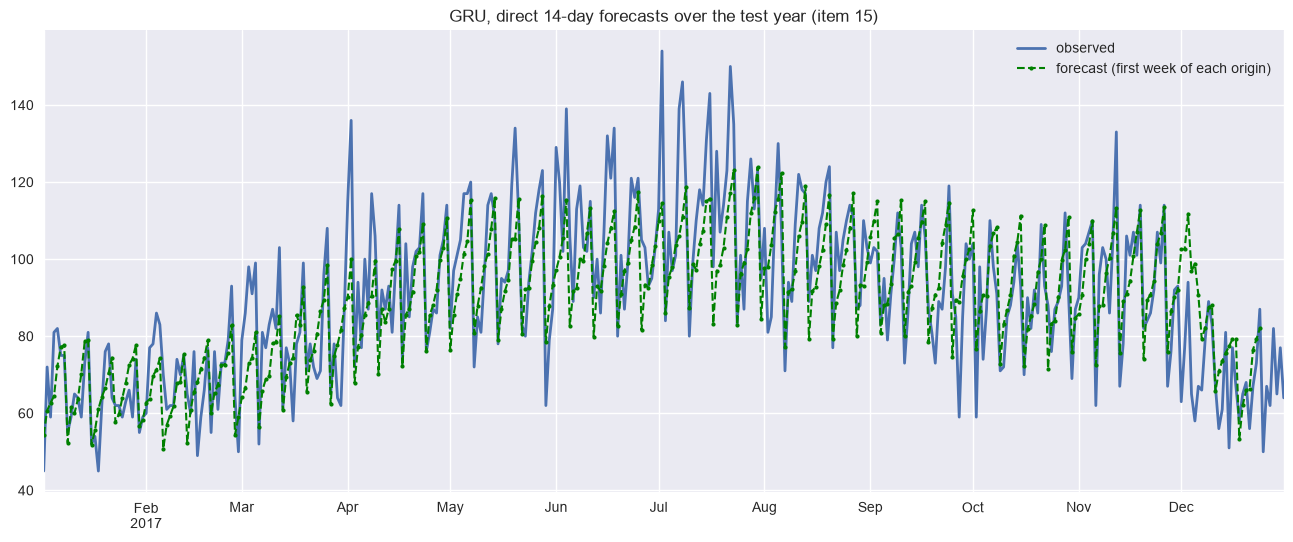

In [19]:
plot_test_forecast(gru_pred, item=15,
                   title='GRU, direct 14-day forecasts over the test year (item 15)')

What the incumbent's forecasts actually look like, for one mid-volume item across the
held-out year. The stitched weekly forecasts track the level, the annual rise and fall,
and the weekly oscillation — the green line is a smoothed shadow of the blue one. What
the model cannot do is predict the day-to-day noise, and it shouldn't: item-level
demand has a large irreducible component, which is why even the winning models below
improve on this picture by tenths of a unit, not by leaps. Keep this plot in mind as
the reference; the interesting differences between architectures will be visible in the
scoreboard, not the eyeball.

# Attention from first principles

Before building transformer forecasters, we build the mechanism itself — small enough
to fit in one NumPy cell — and demonstrate both its superpower and the blind spot that
made vanilla transformers stumble on time series.

In [20]:
def softmax(a):
    """Row-wise softmax: turn scores into weights that are positive and sum to 1."""
    e = np.exp(a - a.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

window = z[100:128, 0]                    # 28 days of item 1, standardized

Q = K = V = window.reshape(-1, 1)         # each day is its own 1-number "token"
scores = Q @ K.T / np.sqrt(Q.shape[1])    # how relevant is day j to day i?
weights = softmax(scores)                 # each row: a probability distribution
attended = weights @ V                    # each day becomes a weighted mix of all days

print(f'weights: {weights.shape}, each row sums to {weights.sum(axis=1)[0]:.4f}')

weights: (28, 28), each row sums to 1.0000


**Scaled dot-product attention** in four lines, on real data: a 28-day slice of item
1's standardized demand, where each day plays the role of a token with an embarrassingly
simple one-dimensional embedding — its own value.

The mechanism has three named roles, all derived from the same tokens here. The
**query** (`Q`) is what each position *asks*; the **key** (`K`) is what each position
*advertises*; the **value** (`V`) is what each position *hands over* if selected. The
matrix product `Q @ K.T` computes every query-key dot product at once — entry `(i, j)`
scores how relevant day `j` is to day `i` — and dividing by the square root of the
embedding dimension (the "scaled" in the name, a formality at dimension 1) keeps scores
in a range where `softmax` does not saturate. The softmax turns each row of scores into
weights that are positive and sum to one, and `weights @ V` replaces each day with a
weighted average of *all* days.

Two properties to notice before we look at the picture. Everything is one matrix
multiplication away from everything else — day 1 influences day 28 as directly as day
27 does, with no 27-step gated relay in between. And nothing anywhere in these four
lines asks *where* a day sits in the window; relevance is decided purely by content.
The first property is the superpower; the second is the blind spot, and we will make
both precise in the next two cells.

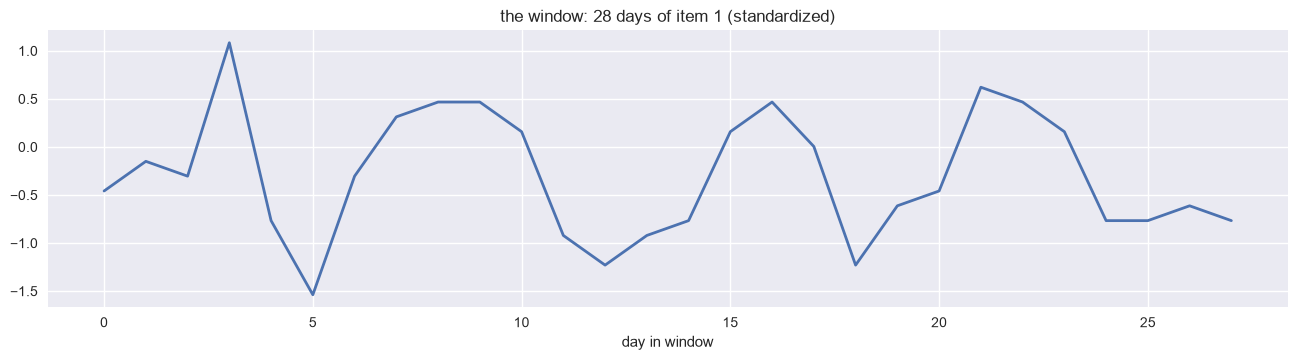

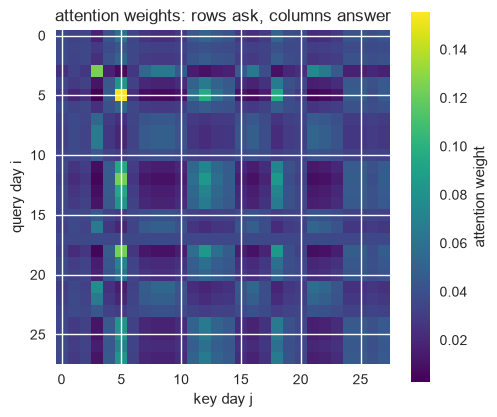

In [21]:
# first the raw material: the window itself
plt.figure(figsize=(CFG.img_dim1, CFG.img_dim2 * 0.6))
plt.plot(window, linewidth=2)
plt.title('the window: 28 days of item 1 (standardized)')
plt.xlabel('day in window')
plt.show()

# then what attention computed from it
plt.figure(figsize=(CFG.img_dim2 * 0.9, CFG.img_dim2 * 0.8))
plt.imshow(weights, cmap='viridis')
plt.colorbar(label='attention weight')
plt.title('attention weights: rows ask, columns answer')
plt.xlabel('key day j')
plt.ylabel('query day i')
plt.show()

Reading the heatmap: row `i` shows how day `i` distributes its one unit of attention
across all 28 days. With raw values as embeddings, the dot product `w[i] * w[j]` is
large and positive when both days are on the same side of the mean — so high-demand
days attend to high-demand days, low-demand days to low-demand days, and the weekly
rhythm of the series shows up as a faint plaid of vertical and horizontal bands. The
model discovers "days like me" without being told anything about weekdays.

This is attention as *content-based lookup*, and it is worth contrasting with the
recurrent alternative explicitly: a GRU relates day 3 to day 24 only through 21
applications of its transition gates, and each application risks diluting the message.
Attention relates them in one step, always, no matter how far apart they are — the
"constant path length" property that makes transformers so good at long-range structure
in every domain. But the lookup is *only* content-based, which has a consequence the
next cell demonstrates.

In [22]:
def attend(x):
    """The four attention lines as a function: values in, mixed values out."""
    q = k = v = x.reshape(-1, 1)
    return (softmax(q @ k.T / np.sqrt(1)) @ v).ravel()

rng = np.random.default_rng(CFG.SEED)
perm = rng.permutation(len(window))       # scramble time
shuffled = window[perm]

print('attention output on the SHUFFLED window == shuffled output on the original?',
      np.allclose(attend(shuffled), attend(window)[perm]))

attention output on the SHUFFLED window == shuffled output on the original? True


The demonstration at the heart of the "are transformers effective for forecasting?"
controversy. We scramble the 28 days into a random order, run attention on the
scrambled window, and compare: the output is **exactly** the original output, just
scrambled the same way. In other words, attention is **permutation-equivariant** —
reorder the inputs and the outputs reorder along, with nothing else changing. No
statistic that attention computes from this window knows whether demand was rising or
falling, whether Monday preceded Tuesday, whether the spike came before the dip.

For language this is a feature: word meaning survives a lot of reordering, and the
mechanism's job is to find related words wherever they sit. For a numerical time
series it is close to a fatal flaw, because a time series *is* its ordering — trend,
seasonality, momentum are all properties of the sequence, not of the bag of values.
A widely cited 2023 AAAI paper ("Are Transformers Effective for Time Series
Forecasting?") pressed exactly this point, calling raw self-attention *anti-order*,
and backed it up by beating a generation of sophisticated transformers with a one-layer
linear model. We will replicate their finding, at miniature scale, later in this
notebook.

The standard patch is to *stamp the position onto the token itself*, so that
content-based lookup can see position as part of the content. That stamp is the
positional encoding, built in the next cell.

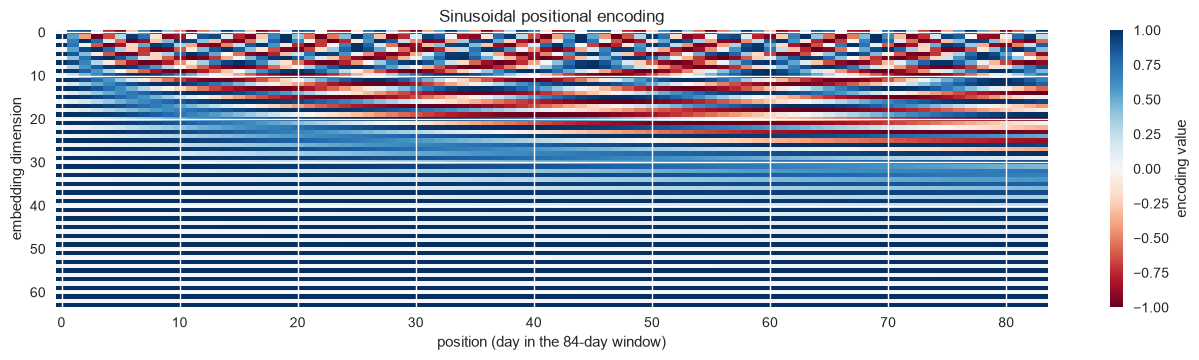

In [23]:
def sinusoidal_pe(length, depth):
    """The original Transformer position stamp: sines and cosines at many scales."""
    pos = np.arange(length)[:, None]          # position index down the rows
    i = np.arange(depth)[None, :]             # embedding dimension across columns
    angle = pos / np.power(10000.0, (2 * (i // 2)) / depth)
    return np.where(i % 2 == 0, np.sin(angle), np.cos(angle)).astype('float32')

pe = sinusoidal_pe(CFG.LOOK_BACK, CFG.D_MODEL)

plt.figure(figsize=(CFG.img_dim1, CFG.img_dim2 * 0.6))
plt.imshow(pe.T, aspect='auto', cmap='RdBu')
plt.colorbar(label='encoding value')
plt.xlabel('position (day in the 84-day window)')
plt.ylabel('embedding dimension')
plt.title('Sinusoidal positional encoding')
plt.show()

Each **position** (a column in the plot) receives a `D_MODEL`-dimensional fingerprint
built from sines and cosines whose wavelengths grow geometrically from ~6 positions
(the fast stripes in the top rows of the plot) to tens of thousands (the bottom rows,
nearly constant across our 84-day window). Adding this fingerprint to a token's embedding gives attention a way to
distinguish day 3 from day 24 even when their demand values are identical: the query-key
dot product now contains position-position terms, and the sinusoid family has the
convenient property that the fingerprint of position `p + k` is a *linear function* of
the fingerprint of position `p` — relative offsets are easy for the network to express.

Two honest caveats, both foreshadowing results to come. First, positional encoding
makes order *recoverable*, not *respected*: the model must spend capacity learning to
use the stamps, whereas a GRU gets temporal order for free from its architecture — an
inductive bias attention gave up. Second, the research record says this patch is only
partly effective for forecasting; the architectures that actually fixed the problem
(patching, axis inversion) changed *what a token is* instead, and they are where this
notebook is headed.

# The transformer ladder

Four architectures, in order of increasing sophistication about what a "token" should
be. Every rung reuses the identical training harness — same windows, same early
stopping, same seed discipline — so the only thing being compared is the architecture.

## Rung 1 — the vanilla transformer: timestamps as tokens

In [24]:
def encoder_block(x, d_model, heads, ff_mult=2, dropout=0.1, name=None):
    """One transformer encoder block: self-attention + feed-forward,
    each wrapped in a residual connection and layer normalization."""
    att = MultiHeadAttention(num_heads=heads, key_dim=d_model // heads,
                             dropout=dropout,
                             name=None if name is None else f'{name}_mha')(x, x)
    x = LayerNormalization()(x + att)
    ff = Dense(d_model * ff_mult, activation='relu')(x)
    ff = Dense(d_model)(ff)
    return LayerNormalization()(x + ff)

The reusable encoder block, assembled from library layers now that the mechanism holds
no mysteries. **`MultiHeadAttention`** is our four NumPy lines, industrialized: the
queries, keys and values are now learned linear projections of the tokens rather than
the tokens themselves, and `num_heads = 4` runs four such projections in parallel —
each head attending in its own `key_dim = d_model / 4`-dimensional subspace, so one
head can specialize in, say, weekly lookups while another tracks the local level. The
call signature `(x, x)` says queries and keys/values both come from the same sequence:
**self**-attention.

The rest of the block is stabilization machinery, and it is not optional. `x + att` is
a **residual connection** — the block learns a *correction* to its input rather than a
replacement, which keeps gradients flowing through deep stacks — and
**`LayerNormalization`** rescales each token's feature vector to zero mean and unit
variance so that scale drift cannot compound across blocks. The two-layer **feed-forward
network** (expand to `d_model * ff_mult` with ReLU, project back) is where per-token
nonlinear processing happens; attention itself only ever *mixes* tokens linearly. This
`attention → add & norm → FFN → add & norm` sandwich is the standard encoder block,
essentially unchanged since 2017; we will stack `N_BLOCKS = 2` of them in every
transformer this episode. The optional `name` tag on the attention layer is plumbing
that lets us pull attention maps out of trained models for inspection later.

In [25]:
def build_vanilla(look_back=CFG.LOOK_BACK, n_channels=CFG.N_ITEMS,
                  horizon=CFG.HORIZON, d_model=CFG.D_MODEL, head='pool'):
    """Vanilla time series transformer: one token per timestamp."""
    pe = sinusoidal_pe(look_back, d_model)
    with keras.device(DEVICE):
        inp = Input(shape=(look_back, n_channels))
        x = Dense(d_model, name='token_embed')(inp) + pe   # embed day, stamp position
        for i in range(CFG.N_BLOCKS):
            x = encoder_block(x, d_model, CFG.N_HEADS, name=f'attn{i + 1}')
        x = GlobalAveragePooling1D()(x) if head == 'pool' else Flatten()(x)
        out = Reshape((horizon, n_channels))(Dense(horizon * n_channels)(x))
        model = Model(inp, out)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(1e-3))
    return model

The direct translation of the NLP recipe to time series — which is exactly how the
first generation of time series transformers worked, and the design whose failure modes
motivated everything after it. The tokenization choice is in the first line of the
graph: `Dense(d_model)` maps **each timestamp's 50-channel snapshot** to a
64-dimensional token, so the sequence handed to attention has 84 tokens, one per day,
and the sinusoidal encoding is added to stamp each with its position. Attention then
operates *across time*: entries in the 84 × 84 attention matrix connect days.

Two design smells are worth calling out now, since the literature later indicts both.
First, a token mixes all fifty items at one instant — the "temporal token" assumes
whatever matters about a timestamp is the joint state of all channels at that exact
tick. Second, single-day tokens carry almost no meaning on their own (one day of noisy
demand is just a number), so attention is asked to find semantic relationships between
nearly semantic-free atoms — this is the point-wise-attention problem that patching
will fix on rung 3.

For the forecast head we pool the 84 processed tokens with `GlobalAveragePooling1D`
and map the pooled vector to all 700 outputs; the `head` argument also offers the
brute-force alternative (`Flatten`, keeping all tokens) whose cost we will see in a
moment. The whole model is 115,708 parameters — bigger than the GRU's 67,772, in the
same small-model league.

In [26]:
keras.utils.set_random_seed(CFG.SEED)
vanilla_model = fit_timed('vanilla transformer', build_vanilla(),
                          X_train, y_train, X_val, y_val)

results['vanilla transformer'] = score_test(vanilla_model.predict(X_test, verbose=0))
results['vanilla transformer']

vanilla transformer: 58 epochs, 11.3s, 115,708 params, best val loss 0.5649


{'MAE': 7.516, 'RMSE': 9.997}

The first upset of the episode, delivered quietly: the vanilla transformer scores RMSE
10.00 — **worse than the GRU's 9.35**, and only modestly better than the
lag-364 copy rule at 10.60. All that parallel attention machinery, the constant
path length to the distant past, the four heads and two blocks... and the sequential
incumbent from 2014 wins.

This replicates, at teaching scale, the finding that shook the field: architectures of
exactly this design — temporal tokens, positional encodings, attention across time —
were the ones a one-layer linear model humiliated in the LTSF-Linear/DLinear paper. The
diagnosis follows from our first-principles section. The mechanism is anti-order and
must *learn* to use its positional stamps from twelve hundred windows; its tokens are
semantically thin single days; and point-wise attention over 84 high-resolution, noisy
tokens gives it every opportunity to overfit high-frequency noise. None of this is a
software bug — it is an inductive-bias mismatch between a set-processing mechanism and
an ordered numerical signal.

In [27]:
keras.utils.set_random_seed(CFG.SEED)
vanilla_flat = fit_timed('vanilla transformer (flat head)',
                         build_vanilla(head='flat'),
                         X_train, y_train, X_val, y_val)

results['vanilla transformer (flat head)'] = score_test(
    vanilla_flat.predict(X_test, verbose=0))
results['vanilla transformer (flat head)']

vanilla transformer (flat head): 19 epochs, 4.5s, 3,834,108 params, best val loss 0.5253


{'MAE': 7.122, 'RMSE': 9.365}

Ruling out the obvious objection — "maybe average-pooling the tokens threw away the
signal" — by re-running with the `Flatten` head, which hands the forecast layer *all*
84 processed tokens. That head alone costs 84 × 64 × 700 weights, ballooning the model
to 3,834,108 parameters, a 3.8-million-parameter monster by this notebook's standards.
The verdict: RMSE 9.37, a dead heat with the 67,772-parameter GRU. Fifty-six
times the parameters to tie the incumbent is not a defense; the problem is not the
head, it is the tokenization — and the next two rungs attack exactly that.

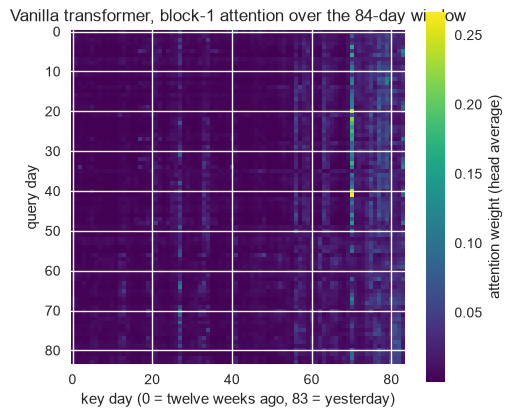

In [28]:
# what did temporal attention learn? pull the map out of the trained model
tokens = Model(vanilla_model.input,
               vanilla_model.get_layer('token_embed').output).predict(
                   X_test[:1], verbose=0) + sinusoidal_pe(CFG.LOOK_BACK, CFG.D_MODEL)

_, att_scores = vanilla_model.get_layer('attn1_mha')(
    tokens, tokens, return_attention_scores=True)
att_scores = keras.ops.convert_to_numpy(att_scores)   # (1, heads, 84, 84)

plt.figure(figsize=(CFG.img_dim2 * 0.9, CFG.img_dim2 * 0.8))
plt.imshow(att_scores[0].mean(axis=0), cmap='viridis')
plt.colorbar(label='attention weight (head average)')
plt.xlabel('key day (0 = twelve weeks ago, 83 = yesterday)')
plt.ylabel('query day')
plt.title('Vanilla transformer, block-1 attention over the 84-day window')
plt.show()

A look inside before moving on, using a two-step extraction idiom worth knowing. First,
`Model(inputs, layer.output)` carves a sub-model that reproduces the trained embedding
of the first test window (we re-add the positional encoding by hand, since it was added
as a constant in the graph). Then the trained `MultiHeadAttention` layer is *called
directly* on those tokens with **`return_attention_scores=True`**, which returns the
`(batch, heads, 84, 84)` weight tensor alongside the output;
`keras.ops.convert_to_numpy` brings it back from the GPU.

The head-averaged map shows what the network chose to do with its freedom: mostly
broad vertical bands — a few informative reference days that *every* query consults,
plus faint periodic texture from the weekly cycle — rather than any crisp temporal
structure like a diagonal (recency) or clean lag-7 stripes. This is the visual
counterpart of the mediocre score: point-wise attention over noisy single-day tokens
learns a soft global averaging scheme, closer to a smoother than to the sharp
"look exactly one year back" behavior a forecaster would want.

## Rung 2 — the linear reality check

In [29]:
def build_linear(look_back=CFG.LOOK_BACK, n_channels=CFG.N_ITEMS,
                 horizon=CFG.HORIZON):
    """One shared linear map from each channel's history to its future."""
    with keras.device(DEVICE):
        inp = Input(shape=(look_back, n_channels))
        x = Permute((2, 1))(inp)          # (channels, time): each channel a row
        x = Dense(horizon)(x)             # the same 84 -> 14 map for every channel
        out = Permute((2, 1))(x)          # back to (time, channels)
        model = Model(inp, out)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(1e-3))
    return model

The bar that any architecture with self-respect must clear, imported from the DLinear /
LTSF-Linear line of work: a **single linear layer** mapping the last 84 days of a
channel to its next 14 days. The `Permute` trick makes it *channel-independent*:
flipping the tensor to `(channels, time)` puts each channel's history in the last axis,
so the `Dense(horizon)` layer — one 84 × 14 weight matrix plus bias, shared by all
fifty items — regresses every channel's future on its own past with the same
coefficients. No attention, no gates, no nonlinearity; 1,190 parameters, roughly the
size of *one row* of the vanilla transformer's output head.

Why is this worth a rung of its own? Because a linear map on a standardized window can
express a surprising amount of forecasting wisdom: weighted seasonal averaging, trend
extrapolation, exponential-decay weighting of recency — all are linear functions of the
history. What it cannot do is interact channels or model nonlinear effects. It is the
perfect control experiment for the question "does the fancy machinery earn its keep?".

In [30]:
keras.utils.set_random_seed(CFG.SEED)
linear_model = fit_timed('linear (channel-independent)', build_linear(),
                         X_train, y_train, X_val, y_val)

results['linear (channel-independent)'] = score_test(
    linear_model.predict(X_test, verbose=0))
results['linear (channel-independent)']

linear (channel-independent): 69 epochs, 4.0s, 1,190 params, best val loss 0.5273


{'MAE': 6.859, 'RMSE': 8.977}

And there it is, the episode's second upset and the honest replication of the DLinear
result: **RMSE 8.98** — better than the GRU (9.35), better than the LSTM,
better than both vanilla transformers, from a model with **1,190 parameters** that
trains in a few seconds. If you take one deployable lesson from this notebook, this is
it: for forecasting tasks dominated by trend and stable seasonality, a per-channel
linear model on a standardized window is a devastating baseline, and any architecture
you propose should be required to beat it.

Why does it win here? The demand panel is close to the linear model's ideal:
overwhelmingly seasonal, locally stable, with little nonlinear structure that 84 days
of a channel's own history doesn't already reveal. The GRU spends its capacity
rediscovering (noisily, from scratch) what the linear map encodes directly in its lag
weights. Note also what the linear model did *not* need: cross-channel information. Its
channel independence — forced by the `Permute` construction — turns out to be a
regularizer, not a handicap, at least at this lookback. The two rungs that remain are
the architectures the field built after absorbing this exact lesson, and both change
the tokenization rather than piling on capacity.

## Rung 3 — patches: give tokens meaning (PatchTST)

In [31]:
def fold_channels(X, y):
    """(N, L, C) -> (N*C, L, 1): every channel becomes its own univariate sample."""
    n, look_back, n_ch = X.shape
    X_flat = X.transpose(0, 2, 1).reshape(n * n_ch, look_back, 1)
    y_flat = y.transpose(0, 2, 1).reshape(n * n_ch, y.shape[1], 1)
    return X_flat, y_flat

def unfold_channels(pred, n_windows):
    """(N*C, H, 1) -> (N, H, C): reassemble per-channel forecasts into a panel."""
    horizon = pred.shape[1]
    return pred.reshape(n_windows, -1, horizon).transpose(0, 2, 1)

X_train_ci, y_train_ci = fold_channels(X_train, y_train)
X_val_ci, y_val_ci = fold_channels(X_val, y_val)
X_test_ci, y_test_ci = fold_channels(X_test, y_test)

print(f'channel-independent training set: {X_train_ci.shape} '
      f'(was {X_train.shape})')

channel-independent training set: (59150, 84, 1) (was (1183, 84, 50))


**Channel independence (CI)**, the first of PatchTST's two ideas, implemented as a data
transformation rather than an architecture: `transpose` and `reshape` turn every
channel of every window into its own *univariate* sample, so the 1,183 multivariate
windows become 59,150 univariate ones, and one shared model trains on all of them. The
linear rung already used CI through weight sharing; this is the same principle at the
dataset level.

The trade embodied here is worth stating carefully, because it contradicts the
intuition that more information must help. A channel-mixing model *could* exploit
cross-item correlations — but with 50 channels and twelve hundred windows it has ample
freedom to hallucinate spurious ones, and the published ablations consistently found CI
transformers *more* accurate and more robust on standard benchmarks. CI also
multiplies the effective sample count by the channel count, which for our
data-starved transformers is no small gift: this is the only model in the episode that
gets fifty-nine thousand training samples. The cost is that genuine cross-channel
signal is invisible — a cost rung 4 is designed to recover.

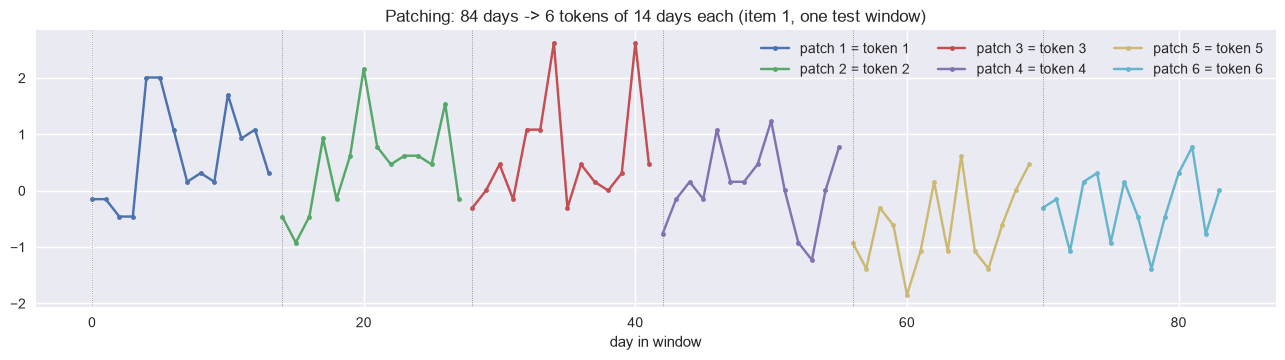

In [32]:
# what patching looks like: one window cut into six two-week tokens
demo = z[test_starts[0] - CFG.LOOK_BACK:test_starts[0], 0]
n_patches = CFG.LOOK_BACK // CFG.PATCH_LEN

plt.figure(figsize=(CFG.img_dim1, CFG.img_dim2 * 0.6))
for p in range(n_patches):
    seg = range(p * CFG.PATCH_LEN, (p + 1) * CFG.PATCH_LEN)
    plt.plot(seg, demo[seg], marker='o', markersize=3.5,
             label=f'patch {p + 1} = token {p + 1}')
    plt.axvline(p * CFG.PATCH_LEN, color='gray', linewidth=0.6, linestyle=':')
plt.title('Patching: 84 days -> 6 tokens of 14 days each (item 1, one test window)')
plt.xlabel('day in window')
plt.legend(ncol=3)
plt.show()

Patching, the second idea, visualized: instead of 84 one-day tokens, cut the window
into `84 / 14 = 6` non-overlapping two-week segments and make **each segment one
token**. Now a token is not a semantic-free single number but a *shape* — fourteen
consecutive days containing two full weekly cycles, with a visible level and slope.
Attention between such tokens compares local patterns ("does the fortnight two months
ago look like the latest fortnight?") rather than raw values, which is a question that
actually has forecasting content.

The benefits compound. Tokens become meaningful; the sequence shrinks from 84 to 6, so
the attention matrix shrinks from 84² to 6² — a 196-fold reduction in attention
entries, which is what lets published PatchTST models afford year-long lookbacks; and
the high-frequency day-to-day noise that point-wise attention could overfit is largely
averaged *inside* the patch embedding. The original paper's title captures the spirit:
"A Time Series is Worth 64 Words".

In [33]:
def build_patchtst(look_back=CFG.LOOK_BACK, horizon=CFG.HORIZON,
                   patch_len=CFG.PATCH_LEN, d_model=CFG.D_MODEL):
    """PatchTST-lite: patch tokens, learned positions, channel-independent."""
    n_patches = look_back // patch_len
    with keras.device(DEVICE):
        inp = Input(shape=(look_back, 1))
        x = Reshape((n_patches, patch_len))(inp)     # cut history into patches
        x = Dense(d_model)(x)                        # embed each patch (a shape!)
        positions = keras.Variable(                  # learned positional encoding
            np.random.normal(0, 0.02, (n_patches, d_model)).astype('float32'),
            name='patch_positions')
        x = x + positions
        for i in range(CFG.N_BLOCKS):
            x = encoder_block(x, d_model, CFG.N_HEADS, name=f'attn{i + 1}')
        x = Flatten()(x)                             # all patch tokens feed the head
        out = Reshape((horizon, 1))(Dense(horizon)(x))
        model = Model(inp, out)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(1e-3))
    return model

The patch transformer, assembled from parts we already understand. `Reshape` performs
the cut (this is why `LOOK_BACK` was chosen divisible by `PATCH_LEN`), and the same
`Dense` layer embeds every 14-day patch into `d_model` dimensions — a learned, shared
"patch reader". Positions are handled with a **learned** encoding this time: a
`keras.Variable` of shape `(6, 64)`, initialized to small noise and trained with
everything else. With only six positions there is no need for the sinusoid family's
extrapolation elegance; six free vectors are simpler and standard in PatchTST
implementations. (`keras.Variable` creates a trainable tensor that is not tied to a
layer — adding it into the graph is enough for backpropagation to find it.)

After two encoder blocks over six tokens, `Flatten` is cheap (6 × 64 = 384 values) —
the wide-head trap of the vanilla model does not exist at patch resolution — and the
linear head maps to the 14-day forecast of *one channel*, because this model is
channel-independent end to end: 73,294 parameters total, in the same league as the
GRU.

In [34]:
keras.utils.set_random_seed(CFG.SEED)
patch_model = fit_timed('PatchTST-lite', build_patchtst(),
                        X_train_ci, y_train_ci, X_val_ci, y_val_ci, batch=256)

patch_pred = unfold_channels(patch_model.predict(X_test_ci, verbose=0),
                             len(test_starts))
results['PatchTST-lite'] = score_test(patch_pred)
results['PatchTST-lite']

PatchTST-lite: 12 epochs, 33.4s, 73,294 params, best val loss 0.5155


{'MAE': 6.948, 'RMSE': 9.137}

Training rides the folded dataset (note `batch=256` — with fifty times the samples we
can afford, and need, bigger batches), and prediction is followed by `unfold_channels`
to reassemble the per-channel forecasts into panel shape before scoring.

The result: RMSE 9.14. Two comparisons locate it. Against the vanilla transformer
(10.00), patching + channel independence claw back nearly a full unit of RMSE —
the two tokenization fixes turn a transformer that *loses* to the GRU into one that
beats it (9.35). Against the linear model (8.98), however, it comes up a
touch short. That, too, faithfully miniaturizes the literature: PatchTST's published
wins over DLinear on the standard benchmarks are real but measured in a few percent,
earned mostly on datasets richer in nonlinear structure than a demand panel — a
well-regularized linear map is brutally hard to beat on stable seasonal data.
The transformer is finally *competitive* — but on this data, attention across time
still has not shown us anything a lag-weighted average couldn't. What we have not yet
tried is attention across *channels*.

## Rung 4 — invert the axes: channels as tokens (iTransformer)

In [35]:
def build_itransformer(look_back=CFG.LOOK_BACK, n_channels=CFG.N_ITEMS,
                       horizon=CFG.HORIZON, d_model=2 * CFG.D_MODEL):
    """iTransformer-lite: one token per CHANNEL, attention across channels."""
    with keras.device(DEVICE):
        inp = Input(shape=(look_back, n_channels))
        x = Permute((2, 1))(inp)                       # the inversion: (channels, time)
        x = Dense(d_model, name='variate_embed')(x)    # a channel's WHOLE history -> one token
        for i in range(CFG.N_BLOCKS):
            x = encoder_block(x, d_model, CFG.N_HEADS, name=f'attn{i + 1}')
        x = Dense(horizon)(x)                          # per-channel forecast head
        out = Permute((2, 1))(x)                       # back to (time, channels)
        model = Model(inp, out)
    model.compile(loss='mse', optimizer=keras.optimizers.Adam(1e-3))
    return model

The final rung keeps every component of the vanilla transformer and changes only the
axis it runs on — a single `Permute` before the embedding. After the flip, the "token
sequence" handed to attention has **fifty tokens, one per item**, and each token embeds
that item's *entire 84-day history* (the `Dense` maps 84 numbers to `d_model = 128`).
Attention entries now connect *channels*: the 50 × 50 attention matrix asks "when
forecasting item 12, which other items' histories are informative?" — exactly the
cross-series structure our correlation heatmap promised, and exactly what every
channel-independent model so far has been unable to touch. This is the
**iTransformer** (ICLR 2024), and the "i" is literally this inversion.

Notice what the inversion dissolves. The permutation-invariance problem is *gone
without positional encodings*: time now lives inside each token along the embedding's
input axis, where the `Dense` map — like the linear rung — reads it with a fixed,
order-aware weight per lag; and channels, the new sequence axis, genuinely *are* an
unordered set, so attention's set-processing nature finally matches its input. The
feed-forward sublayers, which act per token, become per-channel temporal processors.
The forecast head is a per-token `Dense(horizon)` — structurally the linear rung again,
but operating on a 128-dimensional representation that attention has enriched with
information from the 49 sibling channels.

In [36]:
keras.utils.set_random_seed(CFG.SEED)
itransformer_model = fit_timed('iTransformer-lite', build_itransformer(),
                               X_train, y_train, X_val, y_val)

results['iTransformer-lite'] = score_test(
    itransformer_model.predict(X_test, verbose=0))
results['iTransformer-lite']

iTransformer-lite: 30 epochs, 6.6s, 277,646 params, best val loss 0.4572


{'MAE': 6.602, 'RMSE': 8.696}

**RMSE 8.70 — the best score of the episode**, and the first time a transformer
has beaten not just the GRU (9.35, a 7% improvement) but the linear reality check
(8.98). The margin over the linear model is the honest measure of what
cross-channel attention is worth on this panel: about 0.28 RMSE units, earned by
letting fifty noisy views of the same demand climate denoise each other.

The cost side of the ledger is just as instructive: 277,646 parameters — the biggest
*accurate* model of the episode — yet it trained in roughly a third of the GRU's
wall-clock time, because fifty tokens of attention parallelize beautifully on a GPU
while eighty-four sequential GRU steps do not. Sequence length no longer appears in the
attention cost at all; the year-long-lookback experiment below will drive that point
home.

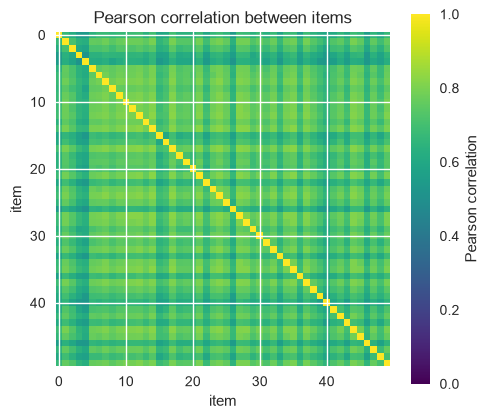

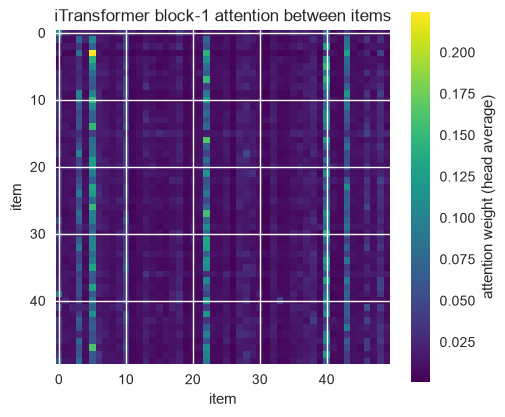

In [37]:
# the learned channel-to-channel attention, next to the raw correlation matrix
variate_tokens = Model(itransformer_model.input,
                       itransformer_model.get_layer('variate_embed').output
                       ).predict(X_test[:1], verbose=0)
_, channel_att = itransformer_model.get_layer('attn1_mha')(
    variate_tokens, variate_tokens, return_attention_scores=True)
channel_att = keras.ops.convert_to_numpy(channel_att)

# the co-movement the data offers ...
plt.figure(figsize=(CFG.img_dim2 * 0.9, CFG.img_dim2 * 0.8))
plt.imshow(corr, cmap='viridis', vmin=0, vmax=1)
plt.colorbar(label='Pearson correlation')
plt.title('Pearson correlation between items')
plt.xlabel('item')
plt.ylabel('item')
plt.show()

# ... and the relationships the model chose to learn
plt.figure(figsize=(CFG.img_dim2 * 0.9, CFG.img_dim2 * 0.8))
plt.imshow(channel_att[0].mean(axis=0), cmap='viridis')
plt.colorbar(label='attention weight (head average)')
plt.title('iTransformer block-1 attention between items')
plt.xlabel('item')
plt.ylabel('item')
plt.show()

The promised diagnostic: the correlation matrix from the groundwork section, followed
by the head-averaged channel-to-channel attention map of the trained iTransformer,
extracted with the same sub-model idiom as before. The attention map is not a copy of the
correlation matrix — it is sparser and more directional, with a handful of columns
lighting up strongly. Columns are *keys*: a bright column means one item's history is
consulted by many other items when they forecast themselves. The model has, in effect,
elected a few high-signal reference items as shared seasonal oracles — a more
economical strategy than attending to everything, and one that pairwise correlation
(symmetric by construction) cannot express. This asymmetry is the fingerprint of
learned, task-driven channel relationships rather than mere co-movement, and it is why
the iTransformer beats models that treat all channels as exchangeable or
independent.

# When transformers win: the lookback sweep

The ladder compared architectures at one fixed window length. But the deepest
difference between recurrence and attention is *how they scale with history*: a GRU
must walk every extra day, step by sequential step, and squeeze it through the same
64-number hidden state, while attention's path length to any past day is constant and
its per-channel token simply grows one more input weight. The report card for that
difference is a sweep over lookback windows — four weeks to a full year — with
everything else held fixed.

In [38]:
SWEEP_LOOKBACKS = [28, 84, 182, 364]     # 4, 12, 26 and 52 weeks of history

sweep_rmse = {'GRU': [], 'iTransformer': []}
sweep_secs = {'GRU': [], 'iTransformer': []}

for lb in SWEEP_LOOKBACKS:
    s_tr, s_va, s_te = split_starts(N_DAYS, lb, CFG.HORIZON, val_start, test_start)
    Xs_tr, ys_tr = make_windows(z, s_tr, lb, CFG.HORIZON)
    Xs_va, ys_va = make_windows(z, s_va, lb, CFG.HORIZON)
    Xs_te, _ = make_windows(z, s_te, lb, CFG.HORIZON)

    for label, build in [('GRU', lambda: build_rnn(GRU, look_back=lb)),
                         ('iTransformer', lambda: build_itransformer(look_back=lb))]:
        keras.utils.set_random_seed(CFG.SEED)
        model = fit_timed(f'{label} (L={lb})', build(), Xs_tr, ys_tr, Xs_va, ys_va)
        pred = model.predict(Xs_te, verbose=0)
        sweep_rmse[label].append(score_in_units(
            pred, s_te, CFG.HORIZON, panel.values, train_mean, train_std)['RMSE'])
        sweep_secs[label].append(train_times[f'{label} (L={lb})'])

pd.DataFrame(sweep_rmse, index=pd.Index(SWEEP_LOOKBACKS, name='lookback days'))

GRU (L=28): 40 epochs, 10.7s, 67,772 params, best val loss 0.5785


iTransformer (L=28): 26 epochs, 6.4s, 270,478 params, best val loss 0.4725


GRU (L=84): 47 epochs, 20.4s, 67,772 params, best val loss 0.5544


iTransformer (L=84): 30 epochs, 6.3s, 277,646 params, best val loss 0.4572


GRU (L=182): 55 epochs, 39.8s, 67,772 params, best val loss 0.5745


iTransformer (L=182): 24 epochs, 4.9s, 290,190 params, best val loss 0.4298


GRU (L=364): 61 epochs, 75.8s, 67,772 params, best val loss 0.5642


iTransformer (L=364): 29 epochs, 5.3s, 313,486 params, best val loss 0.4535


,GRU,iTransformer
lookback days,,
28,9.410,8.668
84,9.349,8.696
182,9.426,8.537
364,9.257,8.388


The loop re-runs the identical recipe — fresh windows, fresh seed, fresh model, same
early stopping — at each window length, for the recurrent standard-bearer and the
episode's champion. One design detail makes the numbers comparable across window
lengths: `split_starts` anchors the test origins to the *label* dates, so all four
sweeps are evaluated on exactly the same 51 weekly forecasts of 2017; only the amount
of visible history changes. (The training set shrinks slightly as the lookback grows,
since early origins no longer fit — from 1,239 windows at four weeks to 903 at a full
year. That handicap works *against* the long-lookback models, which makes the result
below conservative.)

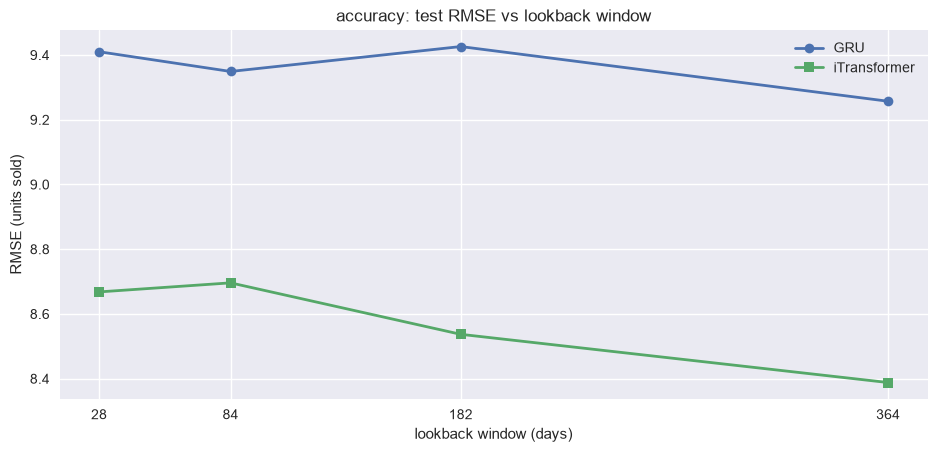

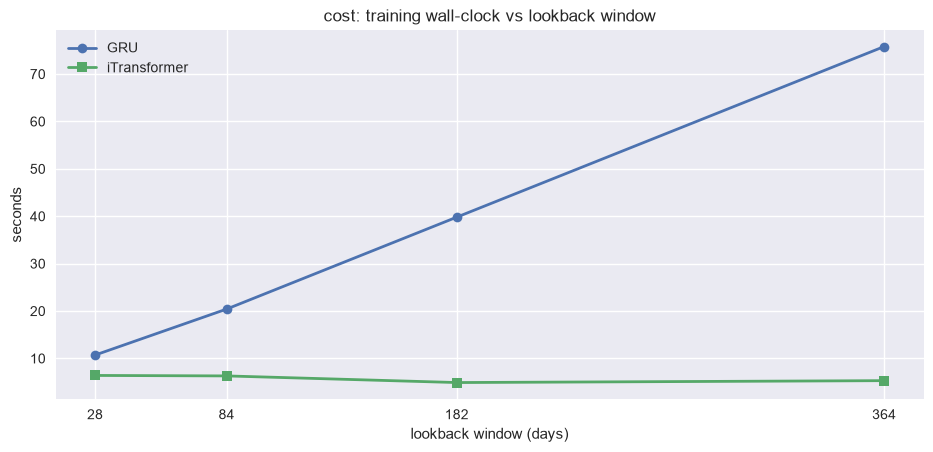

In [39]:
# accuracy as a function of visible history
plt.figure(figsize=(CFG.img_dim1 * 0.7, CFG.img_dim2 * 0.8))
for label, marker in [('GRU', 'o'), ('iTransformer', 's')]:
    plt.plot(SWEEP_LOOKBACKS, sweep_rmse[label], marker=marker, linewidth=2,
             label=label)
plt.title('accuracy: test RMSE vs lookback window')
plt.ylabel('RMSE (units sold)')
plt.xlabel('lookback window (days)')
plt.xticks(SWEEP_LOOKBACKS)
plt.legend()
plt.show()

# training cost as a function of visible history
plt.figure(figsize=(CFG.img_dim1 * 0.7, CFG.img_dim2 * 0.8))
for label, marker in [('GRU', 'o'), ('iTransformer', 's')]:
    plt.plot(SWEEP_LOOKBACKS, sweep_secs[label], marker=marker, linewidth=2,
             label=label)
plt.title('cost: training wall-clock vs lookback window')
plt.ylabel('seconds')
plt.xlabel('lookback window (days)')
plt.xticks(SWEEP_LOOKBACKS)
plt.legend()
plt.show()

This pair of plots is the strongest pro-transformer evidence in the episode, and it is
a *scaling* argument, not a single-number one.

**Accuracy (first plot).** The GRU is flat: RMSE ~9.26–9.43 no matter how much
history it is offered. Give it a full year — long enough to contain last year's
version of every day it must predict — and it cannot cash that in, because 364
sequential gate applications stand between January's signal and the forecast, and a
64-dimensional state is a narrow pipe for a year of fifty channels. The iTransformer
*improves* steadily with lookback, from 8.67 at four weeks to **8.39** at a full
year: each variate token reads the year through a direct linear map (lag 364 is one
weight away, exactly like lag 1), and attention shares the enriched context across
channels. It converts long context into accuracy because, architecturally, nothing
stands in the way.

**Cost (second plot).** The GRU's training time grows roughly linearly with window length
(~10s at four weeks, ~77s at a year — the sequential walk cannot be
parallelized), while the iTransformer's stays essentially constant (~5–7s throughout:
its attention runs over 50 channel tokens regardless of window length, and only the
embedding layer grows). Longer memory is *free* for the inverted transformer and
*linearly expensive* for recurrence.

This is the honest general lesson under the specific numbers: transformers beat
RNNs when the task rewards long context — and only architectures whose tokens make
long context cheap (patches, variate tokens) can exploit that reward in
practice.

# When transformers are overkill: a univariate rematch

Every result so far came from one arena: a 50-channel panel with strong cross-series
structure and a full year of useful context — transformer home turf, chosen partly
*because* it is. Honest evaluation requires the away game too. We return to the
Melbourne daily minimum temperatures of m11: **one** channel, so variate-token
attention has nothing to attend across; a **short** useful memory (tomorrow's
temperature depends on the last few days plus the annual cycle); heavy weather noise;
and 2,900 training windows. The same contenders, rebuilt small, fight on the smaller
task.

In [40]:
# task constants for the rematch
LOOK_BACK_B = 28      # four weeks of history
HORIZON_B = 7         # forecast one week ahead
TEST_DAYS_B = 365     # final year held out
VAL_DAYS_B = 365      # year before that for early stopping
RNN_UNITS_B = 32      # smaller data, smaller recurrent state

temps = pd.read_csv(CFG.data_folder + 'daily-min-temperatures.csv',
                    parse_dates=['Date'], index_col='Date')['Temp'].astype('float32')
N_DAYS_B = len(temps)

test_start_b = N_DAYS_B - TEST_DAYS_B
val_start_b = test_start_b - VAL_DAYS_B
mean_b = temps.values[:val_start_b].mean()
std_b = temps.values[:val_start_b].std()
z_temps = ((temps.values - mean_b) / std_b)[:, None]   # (days, 1): one channel

tr_b, va_b, te_b = split_starts(N_DAYS_B, LOOK_BACK_B, HORIZON_B,
                                val_start_b, test_start_b, test_stride=1)
Xb_train, yb_train = make_windows(z_temps, tr_b, LOOK_BACK_B, HORIZON_B)
Xb_val, yb_val = make_windows(z_temps, va_b, LOOK_BACK_B, HORIZON_B)
Xb_test, yb_test = make_windows(z_temps, te_b, LOOK_BACK_B, HORIZON_B)

print(f'{N_DAYS_B} days of temperatures, '
      f'windows: {len(tr_b)} train / {len(va_b)} val / {len(te_b)} test')

3650 days of temperatures, windows: 2886 train / 359 val / 359 test


The whole groundwork of the first arena, replayed in one cell through the same helpers —
this is what the Utils investment buys. The Melbourne series (1981–1990) is stored as
365-day years with leap days absent, a quirk documented in m11, so ten years is exactly
3,650 rows and a lag of 365 aligns calendar days perfectly. The `[:, None]` reshape
gives the univariate series an explicit channel axis of size one, letting every
multivariate helper and model factory work unchanged. The task mirrors m11's setup at a
weekly horizon: 28 days in, 7 days out, the last year for testing (with *every* day as
a forecast origin now — `test_stride=1` — since evaluation is cheap here), the year
before for validation, eight years to train on.

In [41]:
def score_test_b(pred_z):
    """Score standardized predictions on the temperature test year, in deg C."""
    return score_in_units(pred_z, te_b, HORIZON_B, temps.values, mean_b, std_b)

results_b = {}

persistence = np.repeat(z_temps[te_b - 1][:, None, :], HORIZON_B, axis=1)
results_b['persistence'] = score_test_b(persistence)

naive_365 = np.stack([z_temps[s - 365:s + HORIZON_B - 365] for s in te_b])
results_b['seasonal naive (lag 365)'] = score_test_b(naive_365)

results_b

{'persistence': {'MAE': 2.679, 'RMSE': 3.405},
 'seasonal naive (lag 365)': {'MAE': 2.882, 'RMSE': 3.668}}

Baselines first, as always, and they differ from the demand arena in a telling way.
**Persistence** — tomorrow (and the whole week) equals today — scores RMSE 3.40°C,
*beating* the seasonal naive's 3.67°C. Temperature is a mean-reverting, weather-
dominated signal: the most informative single fact about next week is the current
weather anomaly, not what the calendar said last year. Contrast the demand panel, where
the yearly copy was the baseline to beat. The structure of the best naive forecast is a
cheap diagnostic of what a series rewards — and this one rewards *short* memory, which
should already lower your expectations for architectures whose specialty is long
context.

In [42]:
contenders = {
    'GRU': lambda: build_rnn(GRU, LOOK_BACK_B, 1, HORIZON_B, units=RNN_UNITS_B),
    'LSTM': lambda: build_rnn(LSTM, LOOK_BACK_B, 1, HORIZON_B, units=RNN_UNITS_B),
    'vanilla transformer': lambda: build_vanilla(LOOK_BACK_B, 1, HORIZON_B,
                                                 head='flat'),
    'PatchTST-lite': lambda: build_patchtst(LOOK_BACK_B, HORIZON_B, patch_len=7),
    'linear': lambda: build_linear(LOOK_BACK_B, 1, HORIZON_B),
}

for name, build in contenders.items():
    keras.utils.set_random_seed(CFG.SEED)
    model = fit_timed(f'{name} (temps)', build(),
                      Xb_train, yb_train, Xb_val, yb_val, batch=32)
    results_b[name] = score_test_b(model.predict(Xb_test, verbose=0))

pd.DataFrame(results_b).T

GRU (temps): 60 epochs, 79.0s, 3,591 params, best val loss 0.3918


LSTM (temps): 54 epochs, 53.9s, 4,583 params, best val loss 0.3988


vanilla transformer (temps): 26 epochs, 22.9s, 79,623 params, best val loss 0.4140


PatchTST-lite (temps): 14 epochs, 11.8s, 69,255 params, best val loss 0.4388


linear (temps): 41 epochs, 10.1s, 203 params, best val loss 0.4218


,MAE,RMSE
persistence,2.679,3.405
seasonal naive (lag 365),2.882,3.668
GRU,2.022,2.623
LSTM,2.032,2.651
vanilla transformer,2.025,2.649
PatchTST-lite,2.069,2.691
linear,2.047,2.681


Every factory from the ladder, re-instantiated at rematch scale through their
parameters: 28-day windows, one channel, 7-day horizon, a 32-unit recurrent state,
7-day patches (four per window). The `contenders` dictionary of build-lambdas keeps
the loop honest — one seed reset, one `fit_timed`, one scoring call per model, nothing
bespoke per architecture. (No iTransformer entry: with one channel there is nothing to
invert — a one-token sequence makes attention a no-op. Its natural single-channel
sibling *is* the patch transformer.)

In [43]:
rematch = pd.DataFrame(results_b).T
rematch['params'] = [param_counts.get(f'{m} (temps)', 0) for m in rematch.index]
rematch['train_s'] = [train_times.get(f'{m} (temps)', 0.0) for m in rematch.index]
rematch.sort_values('RMSE')

,MAE,RMSE,params,train_s
GRU,2.022,2.623,3591,79.0
vanilla transformer,2.025,2.649,79623,22.9
LSTM,2.032,2.651,4583,53.9
linear,2.047,2.681,203,10.1
PatchTST-lite,2.069,2.691,69255,11.8
persistence,2.679,3.405,0,0.0
seasonal naive (lag 365),2.882,3.668,0,0.0


The scoreboard of the rematch, and the recurrent incumbent takes it: the **GRU wins at
RMSE 2.62°C with 3,591 parameters** — three orders of magnitude fewer weights
than the vanilla transformer (79,623 parameters, RMSE 2.65) and the patch
transformer (69,255, 2.69), both of which it beats. The 203-parameter linear
model (2.68) lands right between the two transformers. Everything beats both naive baselines
comfortably, so all the models are doing real work; the transformers are simply not
doing *more* work than the cheap alternatives, on a task that has nothing for them:

- **No long-range dependencies to shortcut.** The signal's useful memory is days, not
  seasons — persistence nearly matching learned models told us so. Constant path length
  to the distant past is worthless when the distant past is uninformative.
- **No channels to attend across.** The entire iTransformer/cross-variate axis of
  innovation is undefined at width one.
- **Small, noisy data.** ~2,900 windows of weather noise reward strong inductive
  biases and few parameters; the transformer's flexibility is spent modeling noise, and
  early stopping (note its meager epoch counts) is all that keeps it respectable.

This is the report's engineering guidance made concrete: for low-dimensional,
short-memory, resource-constrained forecasting, **recurrent networks remain the right
tool** — and a linear model should always be in the race. Reaching for a transformer
here buys you 22× the parameters for a slightly *worse* forecast.

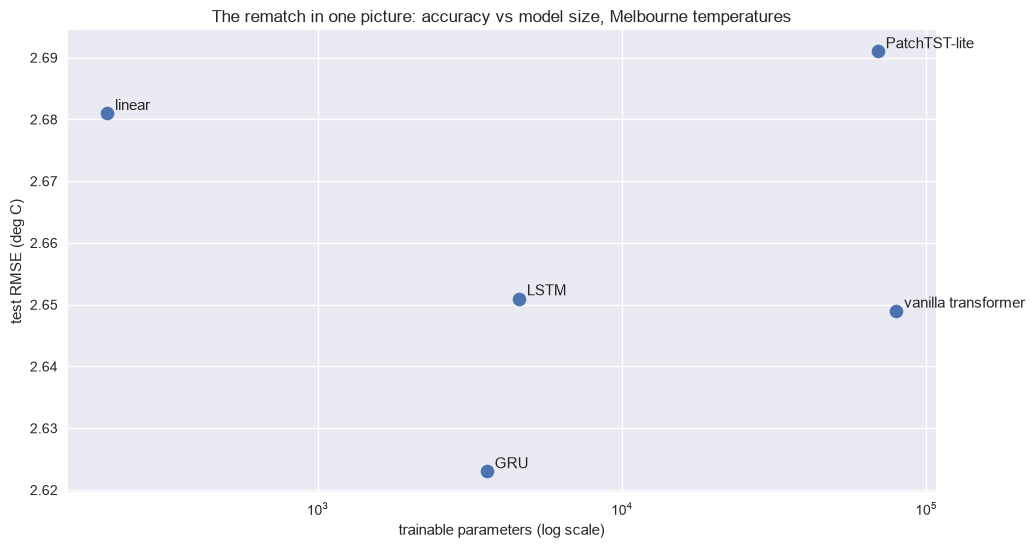

In [44]:
plt.figure(figsize=(CFG.img_dim1 * 0.7, CFG.img_dim2))
learned = rematch[rematch['params'] > 0]
plt.scatter(learned['params'], learned['RMSE'], s=90, zorder=3)
for name, row in learned.iterrows():
    plt.annotate(f'  {name}', (row['params'], row['RMSE']), fontsize=11,
                 va='bottom')
plt.xscale('log')
plt.xlabel('trainable parameters (log scale)')
plt.ylabel('test RMSE (deg C)')
plt.title('The rematch in one picture: accuracy vs model size, Melbourne temperatures')
plt.show()

Accuracy against size on a log axis — the "is it worth it?" plot. Down-left is good.
The GRU sits alone in the bottom-left corner: most accurate *and* nearly the smallest.
The two transformers occupy the far right, paying five-digit parameter counts to land
in the same accuracy band as the 203-parameter linear model. On the demand panel this plot would
look very different (the iTransformer would justify its bulk); the point of drawing it
here is that **the same architectures, competently tuned, reverse their ranking when
the data stops playing to attention's strengths**. Match the tool to the signal, not to
the publication year.

# Head-to-head: the full scoreboard

In [45]:
scoreboard = pd.DataFrame(results).T
scoreboard['params'] = [param_counts.get(m, 0) for m in scoreboard.index]
scoreboard['train_s'] = [train_times.get(m, 0.0) for m in scoreboard.index]
scoreboard.sort_values('RMSE')

,MAE,RMSE,params,train_s
iTransformer-lite,6.602,8.696,277646,6.6
linear (channel-independent),6.859,8.977,1190,4.0
PatchTST-lite,6.948,9.137,73294,33.4
LSTM,6.973,9.328,74940,22.3
GRU,7.022,9.349,67772,19.1
vanilla transformer (flat head),7.122,9.365,3834108,4.5
vanilla transformer,7.516,9.997,115708,11.3
seasonal naive (lag 364),8.180,10.601,0,0.0
seasonal naive (lag 7),8.466,11.019,0,0.0


The demand-panel scoreboard, sorted by RMSE, with the cost columns that turn it from a
leaderboard into an engineering document (zeros mark the naive baselines, which need no
training). Reading it bottom to top tells the episode's story in miniature: the naive
copies at the bottom; the vanilla transformer beating them but losing to the
recurrent incumbents; the incumbents themselves, solid and interchangeable; the
1,190-parameter linear model above them all — the result that forced the field to
rethink; the patch transformer restoring attention to respectability alongside the
linear; and the inverted transformer alone at the top, the only model that extracted
value from the panel's cross-channel structure.

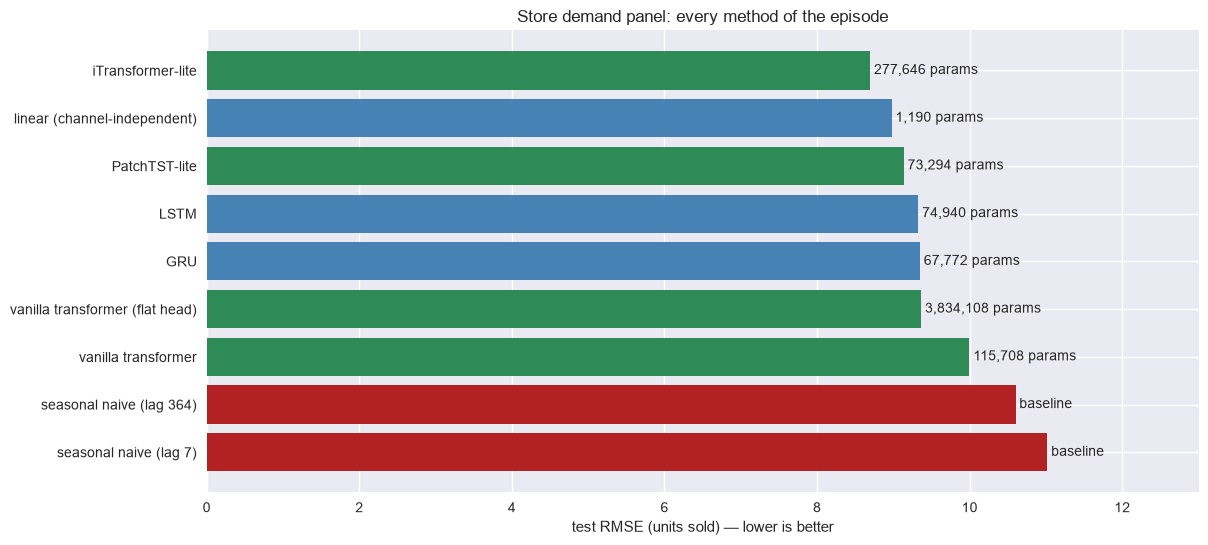

In [46]:
plt.figure(figsize=(CFG.img_dim1 * 0.8, CFG.img_dim2))
ordered = scoreboard.sort_values('RMSE', ascending=False)
colors = ['firebrick' if p == 0 else ('seagreen' if 'ransformer' in m or 'Patch' in m
          else 'steelblue')
          for m, p in zip(ordered.index, ordered['params'])]
plt.barh(ordered.index, ordered['RMSE'], color=colors)
for i, (m, row) in enumerate(ordered.iterrows()):
    label = 'baseline' if row['params'] == 0 else f"{int(row['params']):,} params"
    plt.text(row['RMSE'] + 0.05, i, label, va='center', fontsize=10)
plt.xlabel('test RMSE (units sold) — lower is better')
plt.title('Store demand panel: every method of the episode')
plt.xlim(0, ordered['RMSE'].max() * 1.18)
plt.show()

The same table as a picture: red for naive baselines, blue for recurrent, green for
attention-family (the linear model, ancestor-in-spirit of DLinear, keeps recurrent
blue company as a non-attention method — its bar finishing shorter than both RNNs' is the
plot's quiet scandal). The annotations carry the cost dimension: notice that bar length
is nearly uncorrelated with parameter count, which is the deepest single observation
this episode offers about deep forecasting in the small-data regime.

# Where to go next

This episode built the 2017–2024 arc of transformer forecasting research in miniature:
attention's mechanics, its anti-order paradox, the linear-model humiliation, and the
two tokenization repairs — patches and variate tokens — that made transformers earn
their place. Three directions extend it.

**Hybrids, in both directions.** The boundary between "recurrent" and "attention" is
dissolving. The *iGRU* replaces the iTransformer's cross-channel self-attention with a
GRU run along the channel axis — recurrence as the cheap component, attention's
tokenization retained — and reports competitive accuracy at a fraction of the memory,
attractive when the channel count is in the hundreds. Conversely, hybrid decoders
bolt an LSTM onto a transformer's output to stabilize long horizons: the TSNN-ESTD
line replaces iTransformer's linear decoding layer with an LSTM plus an ensemble of
short-horizon predictions to correct long-horizon bias, reporting 25–33% MSE
reductions at 96–336-step horizons. Our episode's moral — recurrence and attention are
*components with different scaling properties*, not warring religions — is exactly the
premise these designs build on.

**Exogenous variables.** Our panel was self-contained; real demand and load forecasting
come with covariates (weather, prices, calendars) that need not be predicted, only
consulted. Each architecture family fuses them differently — PatchTST-style models keep
channel independence and add a cross-attention sublayer where target patches *query*
covariate patches; iTransformer simply embeds each covariate as one more variate token
and lets cross-variate attention do the rest, which published grid-load benchmarks
found markedly more effective. If you extend this notebook, adding weather tokens to
the iTransformer is the natural experiment — and TimeXer (NeurIPS 2024) is the
reference design.

**Pretraining and foundation models.** Patch tokenization is not just an accuracy fix;
it is what made time series look enough like language for the transfer-learning
playbook of the previous episode to industrialize. Masked-patch reconstruction
(pretrain by hiding random patches, as our m12 masked autoencoder hid timesteps) gives
PatchTST a self-supervised mode that beats its supervised scores on standard
benchmarks, and the same recipe scaled to millions of series yields the foundation
models — MOMENT, Chronos, TimesFM, MOIRAI — whose zero-shot forecasts we discussed
last time. When you meet one, you now know exactly what is inside: patch embeddings,
encoder blocks like `encoder_block`, and a linear head.

Practical guidance, distilled from both arenas: start with seasonal naive and a linear
model on standardized windows — together they are a two-minute, near-zero-parameter
gauntlet that most architectures fail to clear convincingly. Reach for a
recurrent model when the series is low-dimensional and short-memory. Reach for a
transformer when there are *many correlated channels* (iTransformer) or *genuinely
long useful context* (patching) — and when you do, spend your capacity on tokenization
that respects the signal's structure, not on depth. And whatever you deploy, publish
the parameter count and training time next to the RMSE; this episode's scoreboards
are a template for keeping architecture debates honest.